# Specific Test IV — FNO Classifier (Final)
**Input:** 4 channels — Raw · Polar transform · Angular gradient · Radial deviation  
**Model:** Fourier Neural Operator (FNO2d) backbone + classification head  
**Evaluation:** ROC AUC one-vs-rest macro average

In [1]:
import numpy as np
import os, random, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc as sklearn_auc
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
torch.cuda.empty_cache(); gc.collect()
IMG_SIZE = 128

Device : cuda


## 1. Dataset — 4-Channel FNO Input

| Ch | Name | What it encodes |
|---|---|---|
| 0 | Raw (Cartesian) | Absolute flux — standard spatial view |
| 1 | Polar transform | Remaps ring → curved arc in polar space; substructure breaks arc smoothness |
| 2 | Angular gradient `\|dI/dθ\|` | Per-pixel angular intensity change — locates substructure along ring |
| 3 | Radial deviation | `\|I − ring_mean\|` per pixel — measures radial symmetry breaking |

**Augmentation pipeline (correct order):**
1. Geometric aug on **raw only** (flip / rotate / translate)  
2. Compute Ch1–Ch3 from augmented raw → physically consistent  
3. Normalise all 4 channels  
4. RandomErasing on **Ch0 only** — never corrupts symmetry channels

In [2]:
class LensDatasetFNO(Dataset):

    def __init__(self, root_dir, mean=None, std=None, augment=False):
        self.root_dir = root_dir
        self.augment  = augment
        self.mean     = mean
        self.std      = std

        self.paths, self.labels = [], []
        self.classes = sorted([d for d in os.listdir(root_dir)
                                if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        for cls in self.classes:
            for f in sorted(os.listdir(os.path.join(root_dir, cls))):
                if f.endswith(".npy"):
                    self.paths.append(os.path.join(root_dir, cls, f))
                    self.labels.append(self.class_to_idx[cls])

        print(f"  {root_dir}: {len(self.paths)} samples | classes: {self.classes}")

    def __len__(self): return len(self.paths)

    # ── geometric augmentation (on raw only) ─────────────────────────────────
    def _geometric_aug(self, img):
        if random.random() > 0.5: img = TF.hflip(img)
        if random.random() > 0.5: img = TF.vflip(img)
        img = TF.rotate(img, random.uniform(-180, 180), fill=0)
        H, W = img.shape[-2], img.shape[-1]
        tx = int(random.uniform(-0.05, 0.05) * W)
        ty = int(random.uniform(-0.05, 0.05) * H)
        img = TF.affine(img, angle=0, translate=[tx, ty],
                        scale=1.0, shear=0, fill=0)
        return img

    # ── channel builders ──────────────────────────────────────────────────────
    def _polar_transform(self, img):
        """Ch 1: Cartesian → Polar remapping via bilinear grid_sample."""
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
        r_max = min(cx, cy)
        r_vals     = torch.linspace(0, r_max, H)
        theta_vals = torch.linspace(-torch.pi, torch.pi, W)
        R, THETA = torch.meshgrid(r_vals, theta_vals, indexing='ij')
        gx = ((cx + R * torch.cos(THETA)) / (W - 1)) * 2 - 1
        gy = ((cy + R * torch.sin(THETA)) / (H - 1)) * 2 - 1
        grid  = torch.stack([gx, gy], dim=-1).unsqueeze(0)
        polar = F.grid_sample(img.unsqueeze(0), grid, mode='bilinear',
                               padding_mode='zeros', align_corners=True).squeeze()
        return ((polar - polar.min()) / (polar.max() - polar.min() + eps)).unsqueeze(0)

    def _angular_gradient(self, img):
        """Ch 2: |dI/dθ| — angular gradient in polar coords, per pixel."""
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii  = torch.sqrt((xs - cx)**2 + (ys - cy)**2).clamp(min=1.0)
        angles = torch.atan2(ys - cy, xs - cx)
        dtheta = 0.15

        def _sample(r, theta):
            x = (cx + r * torch.cos(theta)) / (W - 1) * 2 - 1
            y = (cy + r * torch.sin(theta)) / (H - 1) * 2 - 1
            return torch.stack([x, y], dim=-1).unsqueeze(0)

        I = img.unsqueeze(0)
        Ip = F.grid_sample(I, _sample(radii, angles + dtheta),
                            mode='bilinear', padding_mode='zeros',
                            align_corners=True).squeeze()
        Im = F.grid_sample(I, _sample(radii, angles - dtheta),
                            mode='bilinear', padding_mode='zeros',
                            align_corners=True).squeeze()
        ag = (Ip - Im).abs() / (2 * dtheta)
        return ((ag - ag.min()) / (ag.max() - ag.min() + eps)).unsqueeze(0)

    def _radial_deviation(self, img):
        """Ch 3: |I - ring_mean| per pixel — radial symmetry breaking."""
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = W / 2.0, H / 2.0
        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii   = torch.sqrt((xs - cx)**2 + (ys - cy)**2)
        bin_idx = (radii / (radii.max() + eps) * 30).long().clamp(0, 29)
        I = img[0]; dev = torch.zeros_like(I)
        for b in range(30):
            mask = (bin_idx == b)
            if mask.sum() > 0:
                dev[mask] = (I[mask] - I[mask].mean()).abs()
        return ((dev - dev.min()) / (dev.max() - dev.min() + eps)).unsqueeze(0)

    def _build_channels(self, raw):
        """Stack all 4 channels → (4, H, W)."""
        return torch.cat([
            raw,
            self._polar_transform(raw),
            self._angular_gradient(raw),
            self._radial_deviation(raw),
        ], dim=0)

    def _normalize(self, x):
        if self.mean is None: return x
        m = torch.tensor(self.mean, dtype=torch.float32).view(-1, 1, 1)
        s = torch.tensor(self.std,  dtype=torch.float32).view(-1, 1, 1)
        return (x - m) / s

    def __getitem__(self, idx):
        raw = torch.tensor(np.load(self.paths[idx]), dtype=torch.float32)
        if raw.ndim == 2: raw = raw.unsqueeze(0)   # (1, H, W)
        raw = F.interpolate(raw.unsqueeze(0), size=128, mode='bilinear', align_corners=False).squeeze(0)

        # 1. Geometric aug on raw only
        if self.augment: raw = self._geometric_aug(raw)

        # 2. Compute all 4 channels from (augmented) raw
        x = self._build_channels(raw)              # (4, H, W)

        # 3. Normalize
        x = self._normalize(x)

        # 4. RandomErasing on Ch0 only
        if self.augment and random.random() < 0.2:
            i, j, h, w, v = transforms.RandomErasing.get_params(
                x[0:1], scale=(0.02, 0.08), ratio=(0.3, 3.3), value=[0])
            x[0, i:i+h, j:j+w] = v

        return x, self.labels[idx]

## 2. Channel Statistics & Loaders

In [3]:
def compute_channel_stats(root_dir, n_channels=4):
    """Compute per-channel mean/std from training set (no augmentation)."""
    ds = LensDatasetFNO(root_dir, augment=False)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=4)
    s1 = torch.zeros(n_channels); s2 = torch.zeros(n_channels); n = 0
    for imgs, _ in loader:
        s1 += imgs.sum(dim=[0, 2, 3])
        s2 += (imgs**2).sum(dim=[0, 2, 3])
        n  += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]
    mean = (s1 / n)
    std  = torch.sqrt((s2/n - mean**2).clamp(min=0)).clamp(min=0.0005)
    print("Mean:", [f'{m:.4f}' for m in mean.tolist()])
    print("Std :", [f'{s:.4f}' for s in std.tolist()])
    return mean.tolist(), std.tolist()

print("Computing channel statistics (train set only — no data leakage)...")
MEAN_FNO, STD_FNO = compute_channel_stats("dataset/train")

train_dataset = LensDatasetFNO("dataset/train", mean=MEAN_FNO, std=STD_FNO, augment=True)
val_dataset   = LensDatasetFNO("dataset/val",   mean=MEAN_FNO, std=STD_FNO, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True)

# sanity check
img, label = train_dataset[0]
print(f"\nInput tensor : {img.shape}  <- (4 channels, 150, 150)")
print(f"Label        : {label}")
assert img.shape[0] == 4, "Must have 4 channels"
print("Shape OK")

Computing channel statistics (train set only — no data leakage)...
  dataset/train: 30000 samples | classes: ['no', 'sphere', 'vort']
Mean: ['0.0617', '0.1033', '0.0372', '0.0427']
Std : ['0.1168', '0.1541', '0.0873', '0.0898']
  dataset/train: 30000 samples | classes: ['no', 'sphere', 'vort']
  dataset/val: 7500 samples | classes: ['no', 'sphere', 'vort']

Input tensor : torch.Size([4, 128, 128])  <- (4 channels, 150, 150)
Label        : 0
Shape OK


  dataset/train: 30000 samples | classes: ['no', 'sphere', 'vort']


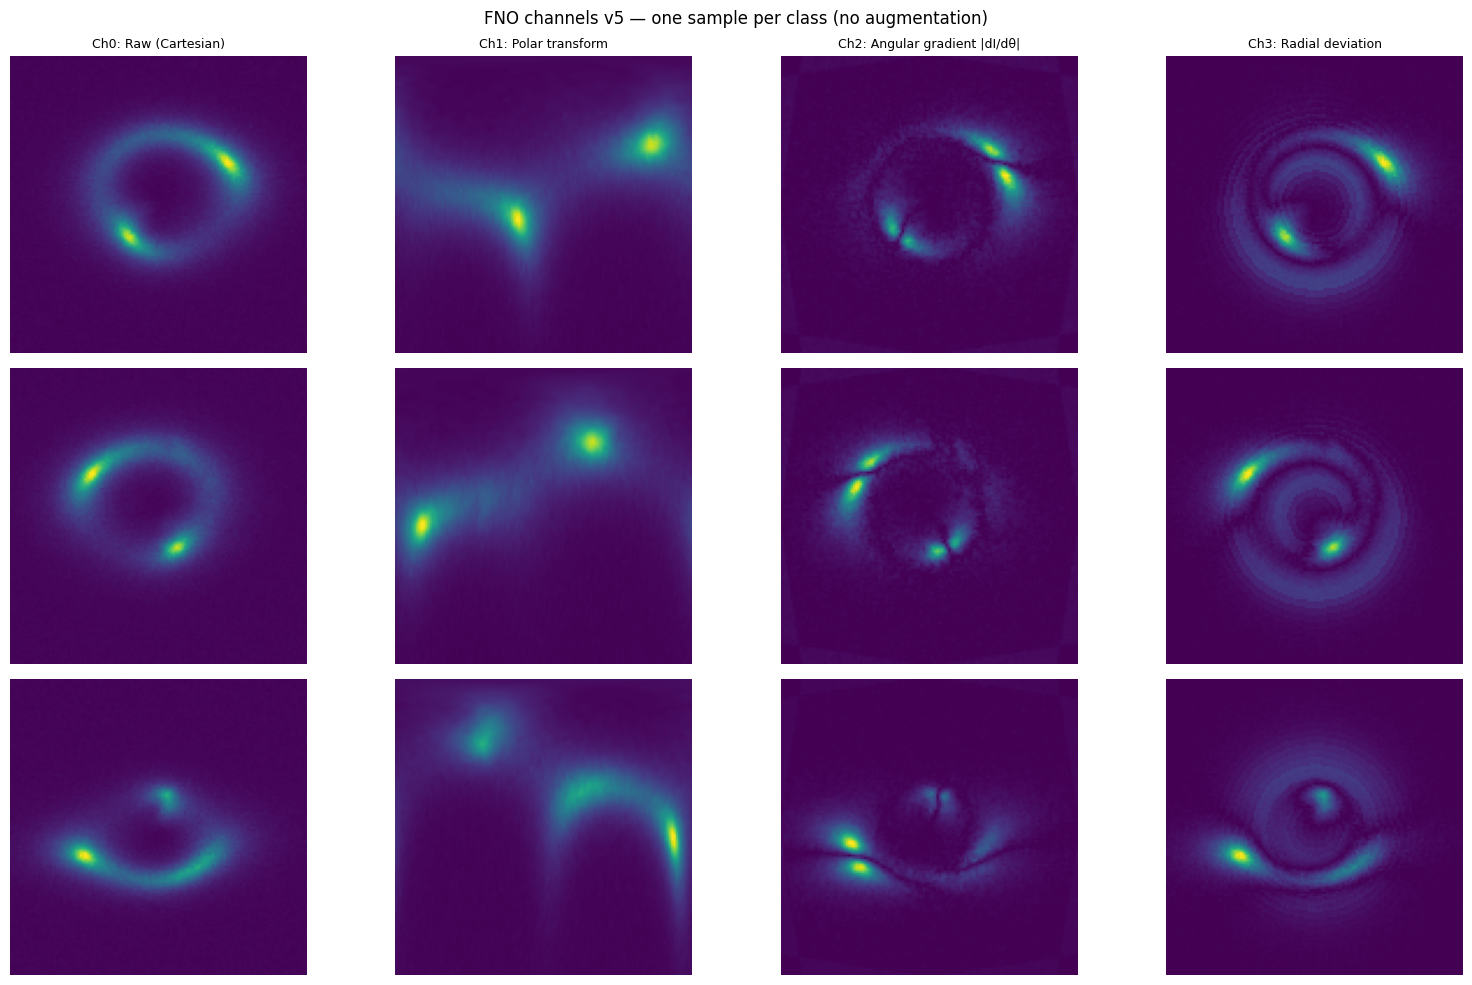

In [4]:
import matplotlib.pyplot as plt

dataset_viz = LensDatasetFNO("dataset/train", augment=False)
class_names = ['no_sub', 'subhalo', 'vortex']
ch_names    = ['Ch0: Raw (Cartesian)',
               'Ch1: Polar transform',
               'Ch2: Angular gradient |dI/dθ|',
               'Ch3: Radial deviation']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for class_idx in range(3):
    # find first sample of each class
    idx = next(i for i, l in enumerate(dataset_viz.labels) if l == class_idx)
    img, _ = dataset_viz[idx]
    for ch in range(4):
        ax = axes[class_idx][ch]
        ax.imshow(img[ch].numpy(), cmap='viridis')
        if class_idx == 0: ax.set_title(ch_names[ch], fontsize=9)
        if ch == 0:        ax.set_ylabel(class_names[class_idx], fontsize=11)
        ax.axis('off')

plt.suptitle('FNO channels v5 — one sample per class (no augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. FNO Architecture

```
(B, 4, 150, 150)  ← 4-channel input
      │
  Lifting Conv2d(4→64) + InstanceNorm + GELU
      │
   ×4  FNOBlock2d
      │   SpectralConv2d  ← learns in Fourier frequency space
      │ + Conv1×1 bypass  ← preserves fine spatial detail
      │   InstanceNorm + GELU
      │
  Projection Conv2d(64→128) + BN + GELU
      │
  AvgPool ‖ MaxPool  →  concat  →  (B, 256)
      │
  FC(256) → BN → GELU → Dropout(0.3) → FC(3)
```

In [5]:
class SpectralConv2d(nn.Module):
    """2D Fourier layer: learns weights in frequency space (global receptive field)."""
    def __init__(self, in_ch, out_ch, m1, m2):
        super().__init__()
        self.out_ch = out_ch
        self.m1, self.m2 = m1, m2
        s = 1.0 / (in_ch * out_ch)
        self.wr1 = nn.Parameter(s * torch.randn(in_ch, out_ch, m1, m2))
        self.wi1 = nn.Parameter(s * torch.randn(in_ch, out_ch, m1, m2))
        self.wr2 = nn.Parameter(s * torch.randn(in_ch, out_ch, m1, m2))
        self.wi2 = nn.Parameter(s * torch.randn(in_ch, out_ch, m1, m2))

    def _cmul(self, xr, xi, wr, wi):
        return (torch.einsum("bixy,ioxy->boxy", xr, wr)
                - torch.einsum("bixy,ioxy->boxy", xi, wi),
                torch.einsum("bixy,ioxy->boxy", xr, wi)
                + torch.einsum("bixy,ioxy->boxy", xi, wr))

    def forward(self, x):
        B, C, H, W = x.shape
        ft = torch.fft.rfft2(x, norm="ortho")
        fr, fi = ft.real, ft.imag
        or_ = torch.zeros(B, self.out_ch, H, W//2+1, device=x.device)
        oi  = torch.zeros_like(or_)
        r1, i1 = self._cmul(fr[:,:,:self.m1,:self.m2],
                             fi[:,:,:self.m1,:self.m2], self.wr1, self.wi1)
        or_[:,:,:self.m1,:self.m2] = r1; oi[:,:,:self.m1,:self.m2] = i1
        r2, i2 = self._cmul(fr[:,:,-self.m1:,:self.m2],
                             fi[:,:,-self.m1:,:self.m2], self.wr2, self.wi2)
        or_[:,:,-self.m1:,:self.m2] = r2; oi[:,:,-self.m1:,:self.m2] = i2
        return torch.fft.irfft2(torch.complex(or_, oi), s=(H, W), norm="ortho")


class FNOBlock2d(nn.Module):
    """SpectralConv2d(x) + Conv1x1(x) -> InstanceNorm -> GELU"""
    def __init__(self, ch, m1, m2):
        super().__init__()
        self.spectral = SpectralConv2d(ch, ch, m1, m2)
        self.bypass   = nn.Conv2d(ch, ch, 1)
        self.norm     = nn.InstanceNorm2d(ch, affine=True)
    def forward(self, x):
        return F.gelu(self.norm(self.spectral(x) + self.bypass(x)))


class FNOClassifier(nn.Module):
    def __init__(self, in_channels=4, width=64, modes=20,
                 depth=4, num_classes=3, dropout=0.3):
        super().__init__()
        self.lift = nn.Sequential(
            nn.Conv2d(in_channels, width, 3, padding=1),
            nn.InstanceNorm2d(width, affine=True), nn.GELU())
        self.blocks  = nn.ModuleList(
            [FNOBlock2d(width, modes, modes) for _ in range(depth)])
        proj = width * 2
        self.project = nn.Sequential(
            nn.Conv2d(width, proj, 1), nn.BatchNorm2d(proj), nn.GELU())
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(proj * 2, 256), nn.BatchNorm1d(256),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.lift(x)
        for blk in self.blocks: x = blk(x)
        x = self.project(x)
        return self.head(torch.cat([self.gap(x), self.gmp(x)], dim=1))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# verify
model = FNOClassifier(in_channels=4)
out   = model(torch.randn(2, 4, 150, 150))
print(f"Output shape : {out.shape}")          # (2, 3)
print(f"Parameters   : {model.count_parameters():,}")
print(f"in_channels  : 4  (Raw + Polar + AngGrad + RadDev)")

Output shape : torch.Size([2, 3])
Parameters   : 26,309,699
in_channels  : 4  (Raw + Polar + AngGrad + RadDev)


## 4. Training

In [6]:
def evaluate(model, loader, device):
    model.eval()
    all_probs, all_labels, total_loss = [], [], 0.0
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    with torch.no_grad():
        for imgs, labs in loader:
            imgs, labs = imgs.to(device), labs.to(device)
            logits = model(imgs)
            total_loss += criterion(logits, labs).item()
            all_probs.append(F.softmax(logits, dim=1).cpu().numpy())
            all_labels.append(labs.cpu().numpy())
    p = np.concatenate(all_probs); l = np.concatenate(all_labels)
    auc = roc_auc_score(l, p, multi_class='ovr', average='macro')
    acc = (p.argmax(1) == l).mean()
    return total_loss / len(loader), acc, auc, p, l


def train_fno(model, train_loader, val_loader, device,
              epochs=50, lr=1e-3, weight_decay=1e-4,
              patience=10, save_path='best_fno.pth'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                   weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1, anneal_strategy='cos',
        div_factor=10.0, final_div_factor=1e3)

    # NO scaler — AMP removed, FNO must run in float32 throughout

    history = {k: [] for k in ['train_loss','val_loss','train_auc',
                                'val_auc','train_acc','val_acc','lr']}
    best_auc = best_epoch = patience_counter = 0

    print("=" * 72)
    print(f"FNO | in_ch=4 | {model.count_parameters():,} params | "
          f"{epochs} epochs | lr={lr}")
    print("=" * 72)
    print(f"{'Ep':>4}  {'TLoss':>7}  {'VLoss':>7}  "
          f"{'T-AUC':>7}  {'V-AUC':>7}  {'T-Acc':>6}  {'V-Acc':>6}")
    print("-" * 72)

    for epoch in range(1, epochs + 1):
        model.train()
        tl, tp, tlab = 0.0, [], []

        for imgs, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            optimizer.zero_grad()
            logits = model(imgs)                          # no autocast
            loss   = criterion(logits, labs)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            tl += loss.item()
            with torch.no_grad():
                tp.append(F.softmax(logits, dim=1).cpu().numpy())  # reuse logits
            tlab.append(labs.cpu().numpy())

        tp = np.concatenate(tp); tlab = np.concatenate(tlab)
        t_auc = roc_auc_score(tlab, tp, multi_class='ovr', average='macro')
        t_acc = (tp.argmax(1) == tlab).mean()
        vl, v_acc, v_auc, _, _ = evaluate(model, val_loader, device)

        for k, v in zip(['train_loss','val_loss','train_auc','val_auc',
                          'train_acc','val_acc','lr'],
                         [tl/len(train_loader), vl, t_auc, v_auc,
                          t_acc, v_acc, optimizer.param_groups[0]['lr']]):
            history[k].append(v)

        flag = " ✓" if v_auc > best_auc else ""
        print(f"{epoch:>4}  {tl/len(train_loader):>7.4f}  {vl:>7.4f}  "
              f"{t_auc:>7.4f}  {v_auc:>7.4f}  {t_acc:>6.2%}  "
              f"{v_acc:>6.2%}{flag}")

        if v_auc > best_auc:
            best_auc = v_auc; best_epoch = epoch; patience_counter = 0
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_auc': best_auc, 'history': history}, save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping (best epoch {best_epoch}, "
                      f"AUC {best_auc:.4f})")
                break

    print(f"\nBest val AUC: {best_auc:.4f} at epoch {best_epoch}")
    return history

In [ ]:
torch.cuda.empty_cache(); gc.collect()

model = FNOClassifier(
    in_channels=4,   # Raw + Polar + AngGrad + RadDev
    width=64,
    modes=20,        # 20/150 ≈ 13% of spectrum — arc morphology band
    depth=4,
    num_classes=3,
    dropout=0.3
).to(DEVICE)

history = train_fno(model, train_loader, val_loader, DEVICE,
                    epochs=50, lr=1e-3, weight_decay=1e-4, patience=10)

FNO | in_ch=4 | 26,309,699 params | 50 epochs | lr=0.001
  Ep    TLoss    VLoss    T-AUC    V-AUC   T-Acc   V-Acc
------------------------------------------------------------------------
   1   1.1326   1.1043   0.5012   0.5223  33.52%  35.29% ✓
   2   1.1143   1.1028   0.5078   0.5461  33.84%  35.95% ✓
   3   1.0970   1.0944   0.5390   0.5713  36.94%  36.36% ✓
   4   1.0827   1.0690   0.5693   0.6248  38.95%  41.53% ✓
   5   1.0686   1.0425   0.5940   0.6511  41.22%  44.44% ✓
   6   1.0479   1.0161   0.6248   0.6915  43.87%  47.03% ✓
   7   1.0254   1.0035   0.6535   0.6994  46.42%  50.28% ✓
   8   1.0011   0.9502   0.6799   0.7334  48.88%  52.83% ✓
   9   0.9797   0.9393   0.7013   0.7456  50.81%  54.72% ✓
  10   0.9542   0.8824   0.7217   0.7765  52.84%  58.96% ✓
  11   0.9343   0.8798   0.7390   0.7873  54.96%  58.68% ✓
  12   0.9173   0.8815   0.7523   0.7926  56.47%  59.29% ✓
  13   0.8957   0.8358   0.7677   0.8131  58.35%  63.12% ✓
  14   0.8791   0.8818   0.7784   0.8118  59.6

In [ ]:
def resume_training(model, train_loader, val_loader, device,
                    checkpoint_path='best_fno.pth',
                    total_epochs=60, lr=2e-4, weight_decay=1e-4,
                    patience=10):

    # ── Load checkpoint ───────────────────────────────────────────────
    ckpt = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(device)

    start_epoch = ckpt['epoch'] + 1          # e.g. 38 if stopped at 37
    best_auc    = ckpt['val_auc']
    best_epoch  = ckpt['epoch']
    history     = ckpt['history']            # continues old history
    patience_counter = 0
    remaining   = total_epochs - ckpt['epoch']

    print(f"Resuming from epoch {ckpt['epoch']}  |  best AUC so far: {best_auc:.4f}")
    print(f"Training from epoch {start_epoch} → {total_epochs}  ({remaining} epochs)")

    # ── Optimizer + scheduler for remaining epochs ────────────────────
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                   weight_decay=weight_decay)
    # CosineAnnealingLR: smoothly decays lr to near-zero over remaining epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=remaining, eta_min=1e-6)

    print("=" * 72)
    print(f"{'Ep':>4}  {'TLoss':>7}  {'VLoss':>7}  "
          f"{'T-AUC':>7}  {'V-AUC':>7}  {'T-Acc':>6}  {'V-Acc':>6}")
    print("-" * 72)

    for epoch in range(start_epoch, total_epochs + 1):
        model.train()
        tl, tp, tlab = 0.0, [], []

        for imgs, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labs)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item()
            with torch.no_grad():
                tp.append(F.softmax(logits, dim=1).cpu().numpy())
            tlab.append(labs.cpu().numpy())

        scheduler.step()   # CosineAnnealingLR steps per epoch (not per batch)

        tp = np.concatenate(tp); tlab = np.concatenate(tlab)
        t_auc = roc_auc_score(tlab, tp, multi_class='ovr', average='macro')
        t_acc = (tp.argmax(1) == tlab).mean()
        vl, v_acc, v_auc, _, _ = evaluate(model, val_loader, device)

        for k, v in zip(['train_loss','val_loss','train_auc','val_auc',
                          'train_acc','val_acc','lr'],
                         [tl/len(train_loader), vl, t_auc, v_auc,
                          t_acc, v_acc, optimizer.param_groups[0]['lr']]):
            history[k].append(v)

        flag = " ✓" if v_auc > best_auc else ""
        print(f"{epoch:>4}  {tl/len(train_loader):>7.4f}  {vl:>7.4f}  "
              f"{t_auc:>7.4f}  {v_auc:>7.4f}  {t_acc:>6.2%}  "
              f"{v_acc:>6.2%}{flag}")

        if v_auc > best_auc:
            best_auc = v_auc; best_epoch = epoch; patience_counter = 0
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_auc': best_auc, 'history': history},
                       checkpoint_path)
            print(f"  → Saved best_fno.pth (AUC {best_auc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping (best epoch {best_epoch}, "
                      f"AUC {best_auc:.4f})")
                break

    print(f"\nBest val AUC: {best_auc:.4f} at epoch {best_epoch}")
    return history


# ── Run it ────────────────────────────────────────────────────────────
history = resume_training(model, train_loader, val_loader, DEVICE,
                          checkpoint_path='best_fno.pth',
                          total_epochs=60,
                          lr=2e-4)        # lower LR since model is already warm

## 5. Final Evaluation

In [ ]:
ckpt = torch.load('best_fno.pth', weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded epoch {ckpt['epoch']} — Val AUC: {ckpt['val_auc']:.4f}")

_, val_acc, val_auc, all_probs, all_labels = evaluate(model, val_loader, DEVICE)
print(f"\nFinal Val AUC : {val_auc:.4f}")
print(f"Final Val Acc : {val_acc:.4f}")

## 6. ROC Curves

In [ ]:
class_names = ['no_sub', 'subhalo', 'vortex']
labels_bin  = label_binarize(all_labels, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen']
aucs   = []
for i, (name, col) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    ra = sklearn_auc(fpr, tpr); aucs.append(ra)
    ax.plot(fpr, tpr, color=col, lw=2.5, label=f"{name}  (AUC = {ra:.4f})")

macro = np.mean(aucs)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title(f'ROC — FNO Classifier  (Macro AUC = {macro:.4f})', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout(); plt.show()

print(f"Macro AUC (FNO)      : {macro:.4f}")
print(f"Macro AUC (ConvNeXt) : 0.9910  [baseline]")
print(f"Delta                : {macro - 0.9910:+.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = all_probs.argmax(axis=1)
cm = confusion_matrix(all_labels, preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — FNO Classifier')
plt.tight_layout(); plt.show()
print(f"Val Accuracy: {(preds == all_labels).mean():.4f}")

## 7. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val')
axes[0].set(title='Loss', xlabel='Epoch'); axes[0].legend()

axes[1].plot(ep, history['train_auc'], label='Train')
axes[1].plot(ep, history['val_auc'],   label='Val')
axes[1].set(title='Macro AUC', xlabel='Epoch'); axes[1].legend()

axes[2].plot(ep, history['lr'])
axes[2].set(title='LR (OneCycleLR)', xlabel='Epoch', yscale='log')

plt.suptitle('FNO Classifier — Training Curves', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Test-Time Augmentation (TTA)

In [ ]:
def evaluate_tta(model, loader, device):
    """8-transform TTA: 4 rotations x 2 flips.
    NOTE: TTA is applied to the FULL 4-channel tensor after channel computation.
    Geometric transforms are valid because all channels are spatially consistent."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labs in loader:
            imgs = imgs.to(device)
            bp   = torch.zeros(imgs.shape[0], 3, device=device)
            for angle in [0, 90, 180, 270]:
                r = TF.rotate(imgs, angle)
                bp += F.softmax(model(r), dim=1)
                bp += F.softmax(model(TF.hflip(r)), dim=1)
            bp /= 8
            all_probs.append(bp.cpu().numpy())
            all_labels.append(labs.numpy())
    p = np.concatenate(all_probs); l = np.concatenate(all_labels)
    auc = roc_auc_score(l, p, multi_class='ovr', average='macro')
    acc = (p.argmax(1) == l).mean()
    print(f"TTA Val AUC: {auc:.4f}  |  TTA Val Acc: {acc:.4f}")
    return acc, auc

tta_acc, tta_auc = evaluate_tta(model, val_loader, DEVICE)

## 9. Comparison vs Baseline

In [ ]:
_, val_acc, val_auc, _, _ = evaluate(model, val_loader, DEVICE)

BASELINE_AUC = 0.9910
BASELINE_ACC = 0.9910

print("=" * 65)
print(f"  {'Metric':<28} {'ConvNeXt V2':>12} {'FNO':>12} {'Delta':>8}")
print("-" * 65)
print(f"  {'Val Macro AUC':<28} {BASELINE_AUC:>12.4f} {val_auc:>12.4f} {val_auc-BASELINE_AUC:>+8.4f}")
print(f"  {'Val Accuracy':<28} {BASELINE_ACC:>12.4f} {val_acc:>12.4f} {val_acc-BASELINE_ACC:>+8.4f}")
print(f"  {'Parameters':<28} {'~28M':>12} {str(model.count_parameters()//1000)+'K':>12}")
print(f"  {'Input resolution':<28} {'224x224':>12} {'150x150':>12}")
print(f"  {'Pretrained (ImageNet)':<28} {'Yes':>12} {'No':>12}")
print(f"  {'Receptive field':<28} {'Local (conv)':>12} {'Global (FFT)':>12}")
print(f"  {'Input channels':<28} {'3 (phys)':>12} {'4 (FNO)':>12}")
print("=" * 65)
print()
print("Channel design:")
print("  CNN : raw + grad_magnitude + laplacian  (pre-compute edges for local conv)")
print("  FNO : raw + polar + angular_grad + radial_dev  (global symmetry features)")
print()
print("Key insight: FNO channels encode GLOBAL ring symmetry properties.")
print("CNN channels encode LOCAL edge/blob features — redundant for FNO.")